In [ ]:
# importing the library or the package

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,r2_score



In [ ]:
#loadding the dataset

In [29]:
df=sns.load_dataset('iris')


In [ ]:
#Exploratory Data Analysi
df.head()
df.describe()

In [ ]:
#preprocessing the targate featur
# encodin it to number for each unique name
le = LabelEncoder()
le.fit_transform(df['species'])

In [ ]:
#splitting features(x) and target(y)

In [52]:
x=df.drop(columns=['species'])
y=df['species']

In [36]:
#splitting the data in training(80%) and testing(20%)
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size =0.2,random_state=42)

In [40]:
#model training and prediction
tibebu = RandomForestClassifier(n_estimators=100,random_state=42)
tibebu.fit(x_train,y_train)
pred=tibebu.predict(x_test)

In [ ]:
# model evalution
y_pred =pred
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

In [ ]:
#evalution the performance of the model using r2_score
encod_y_test =le.transform(y_test)
encod_y_pred =le.transform(y_pred)
r2_score(encod_y_test,encod_y_pred)

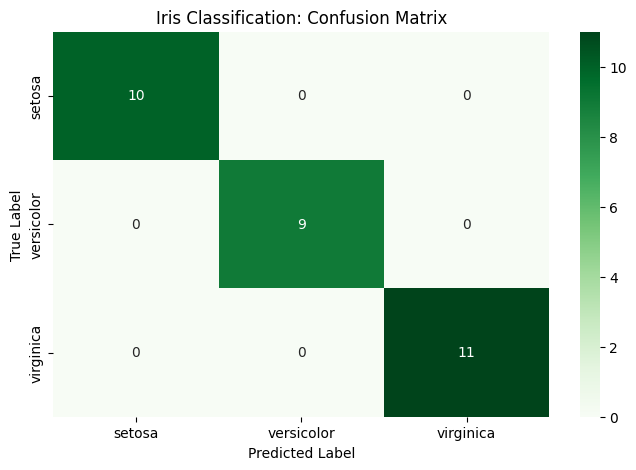

In [55]:
#visualization  of results(confuse matrics)
plt.figure(figsize=(8, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Iris Classification: Confusion Matrix')
plt.show()

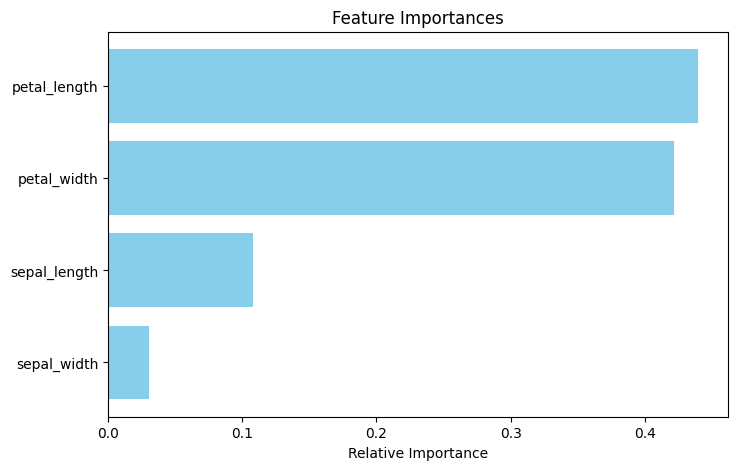

In [54]:
# 7. Visualization 2: Feature Importance (Evaluators love this!)
importances = tibebu.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [x.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()